# Pré-processamento

In [80]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor

In [81]:
#Pré-processamento
df=pd.read_csv('Clean_Dataset.csv')
df.drop(columns=['ID','flight'],inplace=True) #talvez airline?

colunas_categoricas = ['airline','source_city', 'departure_time', 'stops', 'arrival_time', 'destination_city','class']
df = df[df[colunas_categoricas].apply(lambda x: df.duplicated(subset=[x.name], keep=False)).all(axis=1)]

# df = pd.get_dummies(df, columns=[],drop_first=True)
print(df.columns)

Index(['airline', 'source_city', 'departure_time', 'stops', 'arrival_time',
       'destination_city', 'class', 'duration', 'days_left', 'price'],
      dtype='object')


# Execução

In [82]:
# Separação treino e teste

from sklearn.model_selection import train_test_split

X = df.drop(columns=['price'])
y=df['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

In [ ]:
from sklearn.model_selection import cross_val_score,cross_val_predict
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import TargetEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('target_enc', TargetEncoder(cv=10, target_type='continuous'), colunas_categoricas)
    ],
    remainder='passthrough' # Esta flag impede que as numéricas sejam apagadas ou encodadas
)

# O pipeline agora engloba o preprocessor e o modelo
pipeline_protegido = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42,n_jobs=-1))
])

y_pred = cross_val_predict(pipeline_protegido, X_train, y_train, cv=10, verbose=2)

mae=mean_absolute_error(y_train,y_pred)
rmse=np.sqrt(mean_squared_error(y_train,y_pred))
r2=r2_score(y_train,y_pred)

print("\n========================================")
print("       RELATÓRIO DE MÉTRICAS (K=10)     ")
print("========================================")
print(f"MAE (Erro Médio Absoluto): R$ {mae:.2f}")
print(f"RMSE (Raiz do Erro Quadrático): R$ {rmse:.2f}")
print(f"R² (Coeficiente de Determinação): {r2:.4f}")
print("========================================")

[Parallel(n_jobs=1)]: Done   0 out of   1 | elapsed:    4.1s remaining:    4.1s


KeyboardInterrupt: 

In [49]:
# 1. Ajusta o pipeline final usando TODOS os dados de treino de uma vez só
print("Treinando o cérebro final do modelo...")
pipeline_protegido.fit(X_train, y_train)

# 2. Faz o teste real no seu X_test isolado (o "cofre" que ficou guardado)
previsoes_finais = pipeline_protegido.predict(X_test)
print("Modelo pronto e testado!")


Treinando o cérebro final do modelo...
Modelo pronto e testado!


In [52]:
y_train_log = np.log1p(y_train)

# 2. Roda a validação cruzada prevendo o LOG do preço
y_pred_log = cross_val_predict(pipeline_protegido, X_train, y_train_log, cv=10, verbose=2)

# 3. Desfaz o logaritmo para calcular o erro real em Reais
y_pred_real = np.expm1(y_pred_log)

from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
mae=mean_absolute_error(y_train,y_pred_real)
rmse=np.sqrt(mean_squared_error(y_train,y_pred_real))
r2=r2_score(y_train,y_pred_real)

print("\n========================================")
print("       RELATÓRIO DE MÉTRICAS (K=10)     ")
print("========================================")
print(f"MAE (Erro Médio Absoluto): R$ {mae:.2f}")
print(f"RMSE (Raiz do Erro Quadrático): R$ {rmse:.2f}")
print(f"R² (Coeficiente de Determinação): {r2:.4f}")
print("========================================")


       RELATÓRIO DE MÉTRICAS (K=10)     
MAE (Erro Médio Absoluto): R$ 1165.14
RMSE (Raiz do Erro Quadrático): R$ 2761.90
R² (Coeficiente de Determinação): 0.9852


[Parallel(n_jobs=1)]: Done  10 out of  10 | elapsed:  6.1min finished


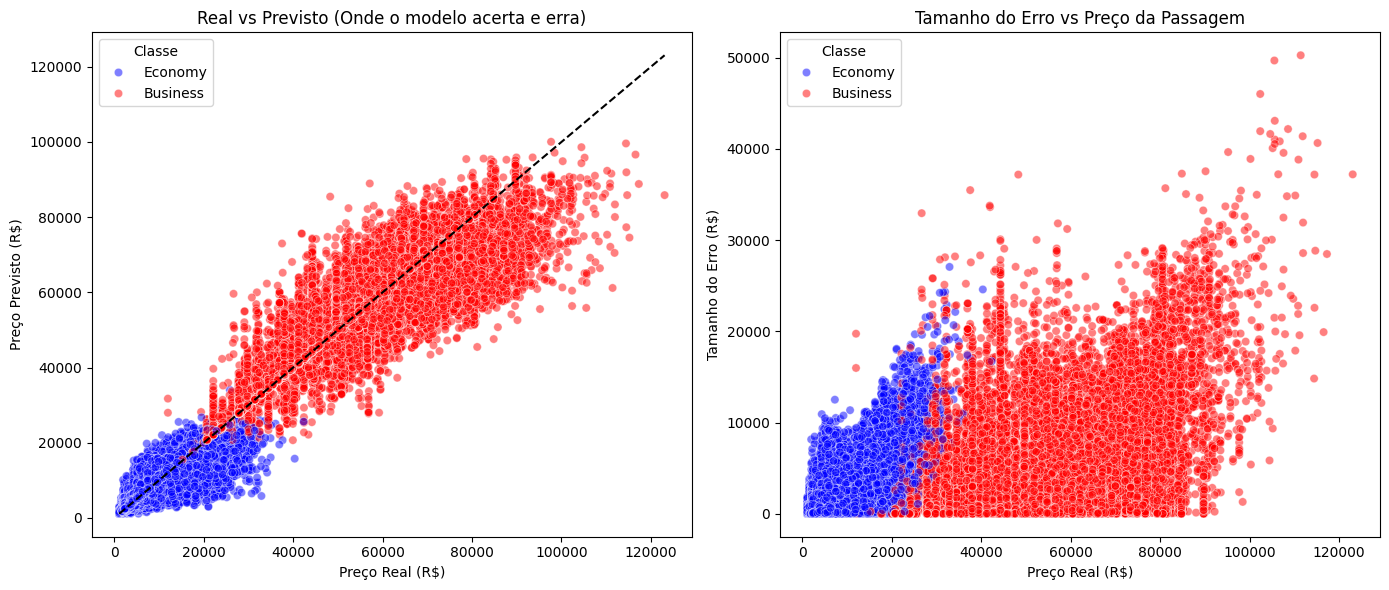


=== MAE (ERRO MÉDIO ABSOLUTO) ISOLADO POR CLASSE ===
Classe
Business    2465.439067
Economy      739.568032
Name: Erro Absoluto, dtype: float64


In [51]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Calcula o erro absoluto de cada predição individual
erros_absolutos = np.abs(y_train - y_pred)

# 2. Cria um DataFrame para facilitar a visualização cruzada
df_diagnostico = pd.DataFrame({
    'Preço Real': y_train,
    'Preço Previsto': y_pred,
    'Erro Absoluto': erros_absolutos,
    'Classe': X_train['class'] # Puxamos a classe para colorir o gráfico
})

# ==========================================
# GRÁFICO 1: Preço Real vs Preço Previsto
# ==========================================
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(data=df_diagnostico, x='Preço Real', y='Preço Previsto', hue='Classe', alpha=0.5, palette={'Economy': 'blue', 'Business': 'red'})
# Linha de perfeição (onde Real = Previsto)
plt.plot([df_diagnostico['Preço Real'].min(), df_diagnostico['Preço Real'].max()], 
         [df_diagnostico['Preço Real'].min(), df_diagnostico['Preço Real'].max()], 
         color='black', linestyle='--')
plt.title('Real vs Previsto (Onde o modelo acerta e erra)')
plt.xlabel('Preço Real (R$)')
plt.ylabel('Preço Previsto (R$)')

# ==========================================
# GRÁFICO 2: Distribuição dos Erros (Resíduos)
# ==========================================
plt.subplot(1, 2, 2)
sns.scatterplot(data=df_diagnostico, x='Preço Real', y='Erro Absoluto', hue='Classe', alpha=0.5, palette={'Economy': 'blue', 'Business': 'red'})
plt.title('Tamanho do Erro vs Preço da Passagem')
plt.xlabel('Preço Real (R$)')
plt.ylabel('Tamanho do Erro (R$)')

plt.tight_layout()
plt.show()

# ==========================================
# ANÁLISE MATEMÁTICA: Erro por Classe
# ==========================================
print("\n=== MAE (ERRO MÉDIO ABSOLUTO) ISOLADO POR CLASSE ===")
print(df_diagnostico.groupby('Classe')['Erro Absoluto'].mean())

# Pipeline economy

In [90]:
# 1. Separa o DataFrame original em dois mundos totalmente isolados
df_economy = df[df['class'] == 'Economy'].copy()
# df_business = df[df['class'] == 'Business'].copy()

# 2. Agora você remove a coluna 'class' de ambos (já que ela virou constante)
df_economy.drop(columns=['class'], inplace=True)
# df_business.drop(columns=['class'], inplace=True)

X = df_economy.drop(columns=['price'])
y=df_economy['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

In [91]:
colunas_categoricas_sem_class=colunas_categoricas.copy()
colunas_categoricas_sem_class.remove('class')
preprocessor = ColumnTransformer(
    transformers=[
        ('target_enc', TargetEncoder(cv=10, target_type='continuous'), colunas_categoricas_sem_class)
    ],
    remainder='passthrough' # Esta flag impede que as numéricas sejam apagadas ou encodadas
)

# O pipeline agora engloba o preprocessor e o modelo
pipeline_protegido = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42,n_jobs=-1))
])

In [92]:
# Acha o valor da passagem na posição 25% e 75% da fila
Q1 = y_train.quantile(0.25)
Q3 = y_train.quantile(0.75)

# Calcula o tamanho do "coração" dos dados
IQR = Q3 - Q1

# Define o teto máximo aceitável
limite_superior = Q3 + 1.5 * IQR

# Filtra o dataframe para treinar apenas com o que é <= ao teto
mascara_inliers = y_train <= limite_superior

X_train_limpo = X_train[mascara_inliers]
y_train_limpo = y_train[mascara_inliers]

In [94]:
y_train_log = np.log1p(y_train_limpo)

# 2. Roda a validação cruzada prevendo o LOG do preço
y_pred_log = cross_val_predict(pipeline_protegido, X_train_limpo, y_train_log, cv=10, verbose=2)

# 3. Desfaz o logaritmo para calcular o erro real em Reais
y_pred_real = np.expm1(y_pred_log)

from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
mae=mean_absolute_error(y_train_limpo,y_pred_real)
rmse=np.sqrt(mean_squared_error(y_train_limpo,y_pred_real))
r2=r2_score(y_train_limpo,y_pred_real)

print("\n========================================")
print("       RELATÓRIO DE MÉTRICAS (K=10)     ")
print("========================================")
print(f"MAE (Erro Médio Absoluto): ₹ {mae:.2f} ou R$ {mae*0.066:.2f}")
print(f"RMSE (Raiz do Erro Quadrático): ₹ {rmse:.2f} ou R$ {rmse*0.066:.2f}")
print(f"R² (Coeficiente de Determinação): {r2:.4f}")
print("========================================")


       RELATÓRIO DE MÉTRICAS (K=10)     
MAE (Erro Médio Absoluto): ₹ 431.03 ou R$ 28.45
RMSE (Raiz do Erro Quadrático): ₹ 868.13 ou R$ 57.30
R² (Coeficiente de Determinação): 0.8895


[Parallel(n_jobs=1)]: Done  10 out of  10 | elapsed:  3.0min finished


In [96]:
import numpy as np

from sklearn.metrics import mean_absolute_percentage_error

def calculate_rmspe(y_true, y_pred):
    # (Real - Previsto) / Real -> Eleva ao quadrado -> Tira a média -> Tira a raiz
    erro_percentual_quadratico = np.square((y_true - y_pred) / y_true)
    return np.sqrt(np.mean(erro_percentual_quadratico))

mape = mean_absolute_percentage_error(y_train_limpo, y_pred_real)
rmspe = calculate_rmspe(y_train_limpo, y_pred_real)

print(f"Erro Percentual Absoluto (MAPE):  {mape * 100:.2f}%")
print(f"Erro Percentual Quadrático (RMSPE): {rmspe * 100:.2f}%")

Erro Percentual Absoluto (MAPE):  7.15%
Erro Percentual Quadrático (RMSPE): 13.03%


# Pipeline bussiness

In [99]:
# 1. Separa o DataFrame original em dois mundos totalmente isolados
#df_economy = df[df['class'] == 'Economy'].copy()
df_business = df[df['class'] == 'Business'].copy()

# 2. Agora você remove a coluna 'class' de ambos (já que ela virou constante)
#df_economy.drop(columns=['class'], inplace=True)
df_business.drop(columns=['class'], inplace=True)

X = df_economy.drop(columns=['price'])
y=df_economy['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

In [100]:
colunas_categoricas_sem_class=colunas_categoricas.copy()
colunas_categoricas_sem_class.remove('class')
preprocessor = ColumnTransformer(
    transformers=[
        ('target_enc', TargetEncoder(cv=10, target_type='continuous'), colunas_categoricas_sem_class)
    ],
    remainder='passthrough' # Esta flag impede que as numéricas sejam apagadas ou encodadas
)

# O pipeline agora engloba o preprocessor e o modelo
pipeline_protegido = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42,n_jobs=-1))
])

In [101]:
# Acha o valor da passagem na posição 25% e 75% da fila
Q1 = y_train.quantile(0.25)
Q3 = y_train.quantile(0.75)

# Calcula o tamanho do "coração" dos dados
IQR = Q3 - Q1

# Define o teto máximo aceitável
limite_superior = Q3 + 1.5 * IQR

# Filtra o dataframe para treinar apenas com o que é <= ao teto
mascara_inliers = y_train <= limite_superior

X_train_limpo = X_train[mascara_inliers]
y_train_limpo = y_train[mascara_inliers]

In [102]:
y_train_log = np.log1p(y_train_limpo)

# 2. Roda a validação cruzada prevendo o LOG do preço
y_pred_log = cross_val_predict(pipeline_protegido, X_train_limpo, y_train_log, cv=10, verbose=2)

# 3. Desfaz o logaritmo para calcular o erro real em Reais
y_pred_real = np.expm1(y_pred_log)

from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
mae=mean_absolute_error(y_train_limpo,y_pred_real)
rmse=np.sqrt(mean_squared_error(y_train_limpo,y_pred_real))
r2=r2_score(y_train_limpo,y_pred_real)

print("\n========================================")
print("       RELATÓRIO DE MÉTRICAS (K=10)     ")
print("========================================")
print(f"MAE (Erro Médio Absoluto): ₹ {mae:.2f} ou R$ {mae*0.066:.2f}")
print(f"RMSE (Raiz do Erro Quadrático): ₹ {rmse:.2f} ou R$ {rmse*0.066:.2f}")
print(f"R² (Coeficiente de Determinação): {r2:.4f}")
print("========================================")


       RELATÓRIO DE MÉTRICAS (K=10)     
MAE (Erro Médio Absoluto): ₹ 431.33 ou R$ 28.47
RMSE (Raiz do Erro Quadrático): ₹ 869.54 ou R$ 57.39
R² (Coeficiente de Determinação): 0.8892


[Parallel(n_jobs=1)]: Done  10 out of  10 | elapsed:  3.0min finished


In [103]:
import numpy as np

from sklearn.metrics import mean_absolute_percentage_error

def calculate_rmspe(y_true, y_pred):
    # (Real - Previsto) / Real -> Eleva ao quadrado -> Tira a média -> Tira a raiz
    erro_percentual_quadratico = np.square((y_true - y_pred) / y_true)
    return np.sqrt(np.mean(erro_percentual_quadratico))

mape = mean_absolute_percentage_error(y_train_limpo, y_pred_real)
rmspe = calculate_rmspe(y_train_limpo, y_pred_real)

print(f"Erro Percentual Absoluto (MAPE):  {mape * 100:.2f}%")
print(f"Erro Percentual Quadrático (RMSPE): {rmspe * 100:.2f}%")

Erro Percentual Absoluto (MAPE):  7.16%
Erro Percentual Quadrático (RMSPE): 13.03%


# Análise de dados

In [7]:
#Listagem quantas categoricas
colunas_categoricas=['source_city', 'departure_time', 'stops', 'arrival_time', 'destination_city', 'class']
contagem_classes = df[colunas_categoricas].nunique()
print(contagem_classes)

source_city         6
departure_time      6
stops               3
arrival_time        6
destination_city    6
class               2
dtype: int64


In [8]:
for coluna in colunas_categoricas:
    classes = df[coluna].unique()
    print(f"📌 Coluna '{coluna}':")
    print(classes)
    print("-" * 40) # Linha divisória para organizar

📌 Coluna 'source_city':
['Delhi' 'Mumbai' 'Bangalore' 'Kolkata' 'Hyderabad' 'Chennai']
----------------------------------------
📌 Coluna 'departure_time':
['Evening' 'Early_Morning' 'Morning' 'Afternoon' 'Night' 'Late_Night']
----------------------------------------
📌 Coluna 'stops':
['zero' 'one' 'two_or_more']
----------------------------------------
📌 Coluna 'arrival_time':
['Night' 'Morning' 'Early_Morning' 'Afternoon' 'Evening' 'Late_Night']
----------------------------------------
📌 Coluna 'destination_city':
['Mumbai' 'Bangalore' 'Kolkata' 'Hyderabad' 'Chennai' 'Delhi']
----------------------------------------
📌 Coluna 'class':
['Economy' 'Business']
----------------------------------------


In [15]:
import numpy as np

# Percorre cada coluna categórica
for coluna in colunas_categoricas:
    print(f"\n📊 ANÁLISE DA COLUNA: {coluna.upper()}")
    print("=" * 50)
    
    # 1. Conta a quantidade absoluta de elementos por classe
    contagem = df[coluna].value_counts()
    
    # 2. Calcula a porcentagem/distribuição de cada classe (multiplica por 100)
    porcentagem = df[coluna].value_counts(normalize=True) * 100
    
    # 3. Junta as duas informações em um único DataFrame para exibição rápida
    analise_coluna = pd.DataFrame({
        'Quantidade': contagem,
        'Distribuição (%)': porcentagem.round(2) # Arredonda para 2 casas decimais
    })
    
    print(analise_coluna)
    print("=" * 50)



📊 ANÁLISE DA COLUNA: SOURCE_CITY
             Quantidade  Distribuição (%)
source_city                              
Delhi             61343             20.44
Mumbai            60896             20.29
Bangalore         52061             17.34
Kolkata           46347             15.44
Hyderabad         40806             13.60
Chennai           38700             12.89

📊 ANÁLISE DA COLUNA: DEPARTURE_TIME
                Quantidade  Distribuição (%)
departure_time                              
Morning              71146             23.70
Early_Morning        66790             22.25
Evening              65102             21.69
Night                48015             16.00
Afternoon            47794             15.92
Late_Night            1306              0.44

📊 ANÁLISE DA COLUNA: STOPS
             Quantidade  Distribuição (%)
stops                                    
one              250863             83.58
zero              36004             12.00
two_or_more       13286              

In [9]:
from sklearn.ensemble import IsolationForest
import seaborn as sns
from sklearn.preprocessing import StandardScaler

df_sem_cat=df.drop(columns=colunas_categoricas)
# scaler = StandardScaler()
# X_escalado = scaler.fit_transform(df_sem_cat)

iso_forest = IsolationForest(contamination=0.001, random_state=42, n_jobs=-1)
outliers = iso_forest.fit_predict(df_sem_cat)

df['is_outlier'] = (outliers == -1)

print("=== CONTAGEM DE OUTLIERS ===")
print(df['is_outlier'].value_counts())

df_10_outliers = df[df['is_outlier'] == True].head(10)
print(df_10_outliers)

=== CONTAGEM DE OUTLIERS ===
is_outlier
False    299852
True        301
Name: count, dtype: int64
      source_city departure_time        stops  ... days_left  price is_outlier
35402       Delhi        Morning  two_or_more  ...         1  18757       True
35403       Delhi        Morning  two_or_more  ...         1  18757       True
35407       Delhi  Early_Morning  two_or_more  ...         1  20071       True
35413       Delhi  Early_Morning  two_or_more  ...         1  23221       True
35499       Delhi        Morning  two_or_more  ...         2  18757       True
35504       Delhi        Morning  two_or_more  ...         2  19597       True
53017      Mumbai  Early_Morning          one  ...         2  21540       True
53030      Mumbai        Morning  two_or_more  ...         2  24531       True
70369      Mumbai        Morning  two_or_more  ...         1  17985       True
70430      Mumbai  Early_Morning          one  ...         2  10777       True

[10 rows x 10 columns]


In [ ]:
import matplotlib.pyplot as plt

plt.scatter(X[:, 0], X[:, 1])
plt.show()